# **MODEL TRAINING WITH ORIGINAL DATA NOTEBOOK**

## **0. Library import**

In [1]:
import os
import sys
# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [2]:
import pandas as pd
import warnings

warnings.filterwarnings(action="ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from src.config import BRFSS_CLEANED_FILE_PATH, LOG_DIR, TRAIN_SIZE, RANDOM_STATE, N_JOBS, \
    SGD_ALPHA, SGD_MAX_ITER, SGD_LOSS, SGD_PENALTY, SGD_LEARNING_RATE, \
    LR_C, LR_PENALTY, LR_CLASS_WEIGHT, LR_VERBOSE, LR_MAX_ITER, LR_SOLVER, \
    RF_N_ESTIMATORS, RF_MAX_DEPTH, RF_MIN_SAMPLES_SPLIT, RF_MIN_SAMPLES_LEAF, RF_CLASS_WEIGHT, \
    NB_ALPHA, NB_TYPE, NB_BINARIZE, NB_VAR_SMOOTHING, \
    XGB_N_ESTIMATORS, XGB_MAX_DEPTH, XGB_LEARNING_RATE, XGB_SUBSAMPLE, XGB_COLSAMPLE_BY_TREE, \
    LGBM_N_ESTIMATORS, LGBM_MAX_DEPTH, LGBM_LEARNING_RATE, LGBM_NUM_LEAVES, LGBM_SUBSAMPLE, LGBM_COLSAMPLE_BY_TREE
from src.evaluate import compare_models
from src.visualization import plot_roc_auc, plot_compare_models
from src.models import (
    DiabetesSGDClassifier, DiabetesLogisticRegression, 
    DiabetesRandomForest, DiabetesNaiveBayes,
    DiabetesXGBoostClassifier, DiabetesLightGBMClassifier
)

## **1. Load dataset**

In [3]:
# Read dataset
df = pd.read_csv(filepath_or_buffer=BRFSS_CLEANED_FILE_PATH)
df.shape

(863745, 34)

In [4]:
# Drop null
df.dropna(inplace=True)
df.shape

(452655, 34)

## **2. Split train and test data**

In [5]:
# Separate features (X) and target variable (y) for model training
X = df.drop(["Diabetes", "Year"], axis=1)
y = df["Diabetes"]

In [6]:
# Apply stratified train-test split to maintain class distributio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (362124, 32)
X_test shape: (90531, 32)
y_train shape: (362124,)
y_test shape: (90531,)


## **3. Data normalization**

In [7]:
# Apply MinMax normalization to scale features to [0,1] ranges
min_max_scaler = MinMaxScaler()
X_train_normalized = min_max_scaler.fit_transform(X=X_train)
X_test_normalized = min_max_scaler.transform(X=X_test)

In [8]:
X_train_normalized[0]

array([0.        , 1.        , 1.        , 0.17241379, 1.        ,
       0.        , 0.        , 1.        , 0.        , 1.        ,
       0.        , 0.5       , 0.        , 0.03333333, 0.        ,
       0.11111111, 0.5       , 0.8       , 0.7       , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.06666667, 0.33333333, 1.        , 1.        , 0.        ,
       0.        , 0.        ])

## **3. Train models**

### **3.1 SGD Classifier**

In [9]:
# Initialize and configure SGD model
sgd_model = DiabetesSGDClassifier(
    loss=SGD_LOSS,
    penalty=SGD_PENALTY,
    alpha=SGD_ALPHA,
    max_iter=SGD_MAX_ITER,
    random_state=RANDOM_STATE,
    learning_rate=SGD_LEARNING_RATE,
    n_jobs=N_JOBS,
    logger_name="models.sgd_classifier",
    log_file=f"{LOG_DIR}/2_model_training_with_original_data.log",
)

2025-09-28 04:30:33,895 - [models.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-28 04:30:33,897 - [models.sgd_classifier] - INFO -   loss: log_loss
2025-09-28 04:30:33,897 - [models.sgd_classifier] - INFO -   penalty: l2
2025-09-28 04:30:33,900 - [models.sgd_classifier] - INFO -   alpha: 0.0001
2025-09-28 04:30:33,901 - [models.sgd_classifier] - INFO -   learning_rate: constant
2025-09-28 04:30:33,902 - [models.sgd_classifier] - INFO -   eta0: 0.01
2025-09-28 04:30:33,903 - [models.sgd_classifier] - INFO -   max_iter: 1000
2025-09-28 04:30:33,904 - [models.sgd_classifier] - INFO -   random_state: 42


In [10]:
# Get the model information
sgd_model.get_model_info()

{'loss': 'log_loss',
 'penalty': 'l2',
 'alpha': 0.0001,
 'learning_rate': 'constant',
 'eta0': 0.01,
 'max_iter': 1000,
 'random_state': 42,
 'model_path': None,
 'is_fitted': False}

In [11]:
# Train the SGD model on normalized training data
sgd_model.train(X=X_train_normalized, y=y_train)

2025-09-28 04:30:33,924 - [models.sgd_classifier] - INFO - Starting SGD Classifier model training...
2025-09-28 04:30:35,396 - [models.sgd_classifier] - INFO - Model training completed. Training samples: 362124
2025-09-28 04:30:35,397 - [models.sgd_classifier] - INFO - Number of iterations: 7


In [12]:
# Generate predictions
sgd_y_pred = sgd_model.predict(X=X_test_normalized)

2025-09-28 04:30:35,428 - [models.sgd_classifier] - INFO - Predictions made for 90531 samples


In [13]:
# Display the first 10 predictions to verify the output format
sgd_y_pred[:10]

array([2., 0., 0., 0., 0., 0., 0., 0., 0., 2.])

In [14]:
# Evaluate SGDClassifier model
sgd_model_eval_results = sgd_model.evaluate(y_true=y_test, y_pred=sgd_y_pred)

2025-09-28 04:30:35,580 - [models.sgd_classifier] - INFO - Model Evaluation Results:
2025-09-28 04:30:35,583 - [models.sgd_classifier] - INFO - Accuracy: 0.8037
2025-09-28 04:30:35,586 - [models.sgd_classifier] - INFO - Precision: 0.4614
2025-09-28 04:30:35,586 - [models.sgd_classifier] - INFO - Recall: 0.4114
2025-09-28 04:30:35,588 - [models.sgd_classifier] - INFO - F1-Score: 0.4202
2025-09-28 04:30:35,637 - [models.sgd_classifier] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.95      0.89     71499
         1.0       0.00      0.00      0.00      2399
         2.0       0.55      0.28      0.37     16633

    accuracy                           0.80     90531
   macro avg       0.46      0.41      0.42     90531
weighted avg       0.76      0.80      0.77     90531

2025-09-28 04:30:35,682 - [models.sgd_classifier] - INFO - Confusion Matrix:
[[68067     0  3432]
 [ 2067     0   332]
 [11941     0  4692]]


In [15]:
# Display model performance metrics
sgd_model_eval_results

{'accuracy': 0.8036915531696325,
 'precision': 0.4613997050831798,
 'recall': 0.4113630500337489,
 'f1_score': 0.42015585649135206}

In [16]:
# Predict class probabilities
sgd_class_probabilities = sgd_model.predict_proba(X=X_test_normalized)

2025-09-28 04:30:35,742 - [models.sgd_classifier] - INFO - Probabilities predicted for 90531 samples


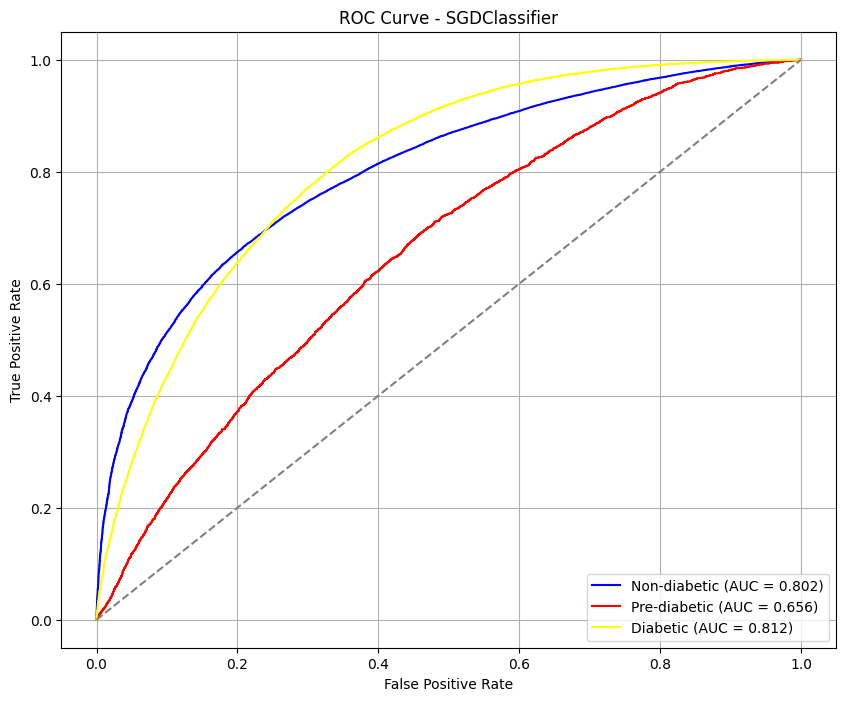

In [17]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=sgd_class_probabilities,
    model_name="SGDClassifier"
)

In [18]:
# Evaluate SGDClassifier model with cross-validation
sgd_model_cv_scores = sgd_model.cross_validate(X=X_train_normalized, y=y_train)
sgd_model_cv_scores

2025-09-28 04:30:41,806 - [models.sgd_classifier] - INFO - Cross-validation results:
2025-09-28 04:30:41,808 - [models.sgd_classifier] - INFO - Mean accuracy: 0.8029 (+/- 0.0015)


array([0.80234726, 0.80277528, 0.80193303, 0.80327235, 0.80405667])

### **3.2 Logistic Regression**

In [19]:
# Initialize and configure Logistic Regression model
lr_model = DiabetesLogisticRegression(
    C=LR_C, 
    penalty=LR_PENALTY, 
    class_weight=LR_CLASS_WEIGHT,
    max_iter=LR_MAX_ITER, 
    solver=LR_SOLVER,
    random_state=RANDOM_STATE,
    verbose=LR_VERBOSE,
    n_jobs=N_JOBS,
    logger_name="models.logistic_regression",
    log_file=f"{LOG_DIR}/2_model_training_with_original_data.log",
)

2025-09-28 04:30:41,831 - [models.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-28 04:30:41,833 - [models.logistic_regression] - INFO -   C: 1.0
2025-09-28 04:30:41,834 - [models.logistic_regression] - INFO -   penalty: l2
2025-09-28 04:30:41,836 - [models.logistic_regression] - INFO -   class_weight: None
2025-09-28 04:30:41,839 - [models.logistic_regression] - INFO -   solver: saga
2025-09-28 04:30:41,841 - [models.logistic_regression] - INFO -   max_iter: 10000
2025-09-28 04:30:41,843 - [models.logistic_regression] - INFO -   random_state: 42


In [20]:
# Get the model information
lr_model.get_model_info()

{'C': 1.0,
 'penalty': 'l2',
 'solver': 'saga',
 'max_iter': 10000,
 'random_state': 42,
 'model_path': None}

In [21]:
# Train Logistic Regression model on normalized training data
lr_model.train(X=X_train_normalized, y=y_train)

2025-09-28 04:30:41,911 - [models.logistic_regression] - INFO - Starting Logistic Regression model training...
2025-09-28 04:30:49,798 - [models.logistic_regression] - INFO - Model training completed. Training samples: 362124


In [22]:
# Generate predictions
lr_y_pred = lr_model.predict(X=X_test_normalized)

2025-09-28 04:30:49,822 - [models.logistic_regression] - INFO - Predictions made for 90531 samples


In [23]:
# Display the first 10 predictions to verify the output format
lr_y_pred[:10]

array([2., 0., 0., 0., 0., 0., 0., 0., 0., 2.])

In [24]:
# Evaluate LogisticRegression model
lr_model_eval_results = lr_model.evaluate(y_true=y_test, y_pred=lr_y_pred)

2025-09-28 04:30:49,964 - [models.logistic_regression] - INFO - Model Evaluation Results:
2025-09-28 04:30:49,970 - [models.logistic_regression] - INFO - Accuracy: 0.8046
2025-09-28 04:30:49,974 - [models.logistic_regression] - INFO - Precision: 0.4653
2025-09-28 04:30:49,977 - [models.logistic_regression] - INFO - Recall: 0.4056
2025-09-28 04:30:49,980 - [models.logistic_regression] - INFO - F1-Score: 0.4142
2025-09-28 04:30:50,029 - [models.logistic_regression] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.96      0.89     71499
         1.0       0.00      0.00      0.00      2399
         2.0       0.57      0.26      0.36     16633

    accuracy                           0.80     90531
   macro avg       0.47      0.41      0.41     90531
weighted avg       0.76      0.80      0.77     90531

2025-09-28 04:30:50,067 - [models.logistic_regression] - INFO - Confusion Matrix:
[[68547     0  2952]
 [ 2111     0   

In [25]:
# Display model performance metrics
lr_model_eval_results

{'accuracy': 0.8045973202549404,
 'precision': 0.46528229452520065,
 'recall': 0.40562473182359654,
 'f1_score': 0.4142411317781784}

In [26]:
# Predict class probabilities
lr_class_probabilities = lr_model.predict_proba(X=X_test_normalized)

2025-09-28 04:30:50,116 - [models.logistic_regression] - INFO - Probabilities predicted for 90531 samples


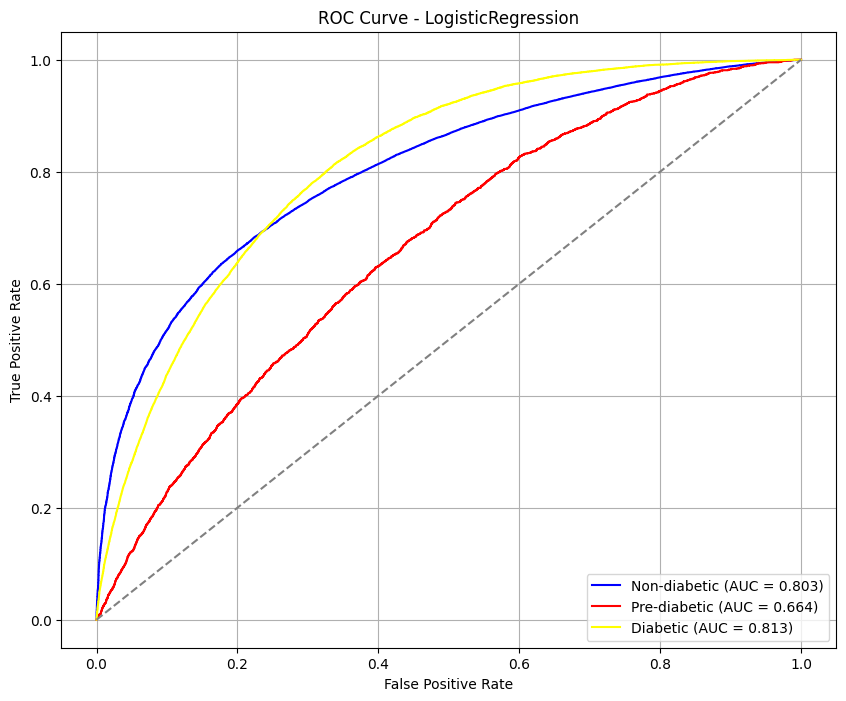

In [27]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=lr_class_probabilities,
    model_name="LogisticRegression"
)

In [28]:
# Evaluate Logistic Regression with cross-validation
lr_model_cv_scores = lr_model.cross_validate(X=X_train_normalized, y=y_train)
lr_model_cv_scores

2025-09-28 04:31:20,448 - [models.logistic_regression] - INFO - Cross-validation results:
2025-09-28 04:31:20,450 - [models.logistic_regression] - INFO - Mean accuracy: 0.8048 (+/- 0.0009)


array([0.80462547, 0.80492924, 0.80538488, 0.80414222, 0.80514746])

### **3.3 Naive Bayes**

In [29]:
# Initialize and configure Gaussian Naive Bayes model
nb_model = DiabetesNaiveBayes(
    nb_type=NB_TYPE,
    var_smoothing=NB_VAR_SMOOTHING,
    binarize=NB_BINARIZE,
    alpha=NB_ALPHA,
    logger_name="models.naive_bayes",
    log_file=f"{LOG_DIR}/2_model_training_with_original_data.log",
)

2025-09-28 04:31:20,472 - [models.naive_bayes] - INFO - DiabetesNaiveBayes (Gaussian) initialized with parameters:
2025-09-28 04:31:20,475 - [models.naive_bayes] - INFO -   nb_type: gaussian
2025-09-28 04:31:20,477 - [models.naive_bayes] - INFO -   var_smoothing: 1e-09


In [30]:
# Get the model information
nb_model.get_model_info()

{'nb_type': 'gaussian',
 'var_smoothing': 1e-09,
 'model_path': None,
 'is_fitted': False}

In [31]:
# Train Naive Bayes model on normalized training data
nb_model.train(X=X_train_normalized, y=y_train)

2025-09-28 04:31:20,528 - [models.naive_bayes] - INFO - Starting Gaussian Naive Bayes model training...
2025-09-28 04:31:20,753 - [models.naive_bayes] - INFO - Model training completed. Training samples: 362124
2025-09-28 04:31:20,754 - [models.naive_bayes] - INFO - Number of classes: 3
2025-09-28 04:31:20,755 - [models.naive_bayes] - INFO - Classes: [0. 1. 2.]


In [32]:
# Generate predictions
nb_y_pred = nb_model.predict(X=X_test_normalized)

2025-09-28 04:31:20,812 - [models.naive_bayes] - INFO - Predictions made for 90531 samples


In [33]:
# Display the first 10 predictions to verify the output format
nb_y_pred[:10]

array([2., 0., 0., 0., 0., 0., 0., 0., 0., 2.])

In [34]:
# Evaluate NaiveBayes model
nb_model_eval_results = nb_model.evaluate(y_true=y_test, y_pred=nb_y_pred)

2025-09-28 04:31:20,875 - [models.naive_bayes] - INFO - Model Evaluation Results:
2025-09-28 04:31:20,876 - [models.naive_bayes] - INFO - Accuracy: 0.7108
2025-09-28 04:31:20,876 - [models.naive_bayes] - INFO - Precision: 0.4322
2025-09-28 04:31:20,877 - [models.naive_bayes] - INFO - Recall: 0.4616
2025-09-28 04:31:20,878 - [models.naive_bayes] - INFO - F1-Score: 0.4377
2025-09-28 04:31:20,917 - [models.naive_bayes] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.76      0.81     71499
         1.0       0.06      0.04      0.05      2399
         2.0       0.37      0.58      0.45     16633

    accuracy                           0.71     90531
   macro avg       0.43      0.46      0.44     90531
weighted avg       0.76      0.71      0.73     90531

2025-09-28 04:31:20,956 - [models.naive_bayes] - INFO - Confusion Matrix:
[[54629  1343 15527]
 [ 1351   102   946]
 [ 6613   403  9617]]


In [35]:
# Display model performance metrics
nb_model_eval_results

{'accuracy': 0.7107841512851951,
 'precision': 0.43218959757121417,
 'recall': 0.4615860998152915,
 'f1_score': 0.4376783893997563}

In [36]:
# Predict class probabilities
nb_class_probabilities = nb_model.predict_proba(X=X_test_normalized)

2025-09-28 04:31:21,033 - [models.naive_bayes] - INFO - Probabilities predicted for 90531 samples


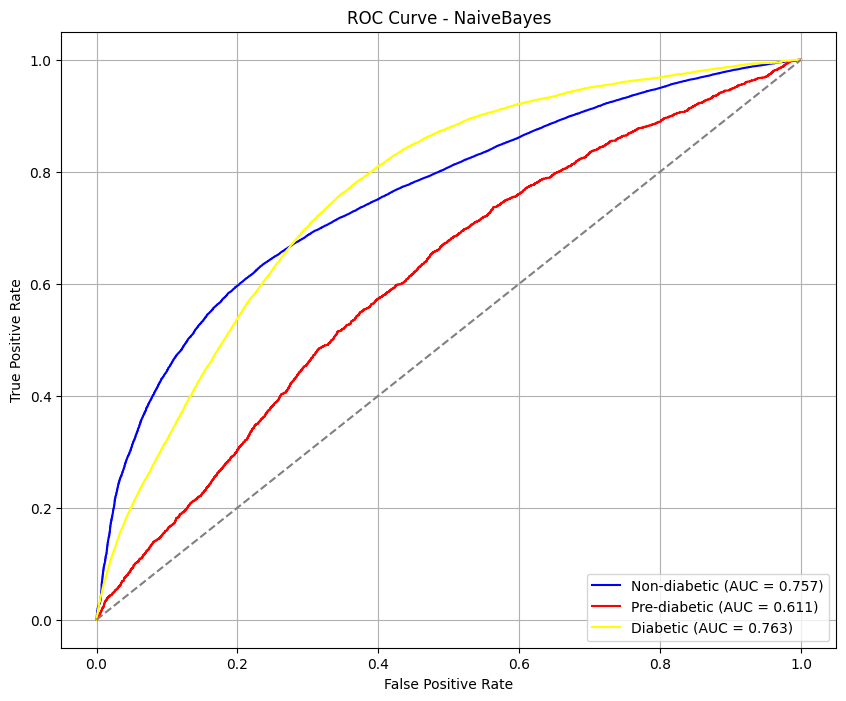

In [37]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=nb_class_probabilities,
    model_name="NaiveBayes"
)

In [38]:
# Evaluate Naive Bayes with cross-validation
nb_model_cv_scores = nb_model.cross_validate(X=X_train_normalized, y=y_train)
nb_model_cv_scores

2025-09-28 04:31:22,661 - [models.naive_bayes] - INFO - Cross-validation results:
2025-09-28 04:31:22,661 - [models.naive_bayes] - INFO - Mean accuracy: 0.7096 (+/- 0.0024)


array([0.70900932, 0.71192268, 0.70838799, 0.70936831, 0.70912957])

### **3.4 Random Forest**

In [39]:
# Initialize and configure a Random Forest model
rf_model = DiabetesRandomForest(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_split=RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    class_weight=RF_CLASS_WEIGHT,
    random_state=RANDOM_STATE,
    logger_name="models.random_forest",
    log_file=f"{LOG_DIR}/2_model_training_with_original_data.log",
)

2025-09-28 04:31:22,675 - [models.random_forest] - INFO - DiabetesRandomForest initialized with parameters:
2025-09-28 04:31:22,676 - [models.random_forest] - INFO -   n_estimators: 100
2025-09-28 04:31:22,677 - [models.random_forest] - INFO -   max_depth: 25
2025-09-28 04:31:22,678 - [models.random_forest] - INFO -   min_samples_split: 5
2025-09-28 04:31:22,679 - [models.random_forest] - INFO -   min_samples_leaf: 5
2025-09-28 04:31:22,680 - [models.random_forest] - INFO -   max_features: sqrt
2025-09-28 04:31:22,681 - [models.random_forest] - INFO -   class_weight: balanced
2025-09-28 04:31:22,682 - [models.random_forest] - INFO -   random_state: 42


In [40]:
# Get the model information
rf_model.get_model_info()

{'n_estimators': 100,
 'max_depth': 25,
 'min_samples_split': 5,
 'min_samples_leaf': 5,
 'max_features': 'sqrt',
 'random_state': 42,
 'model_path': None}

In [41]:
# Train the Random Forest model on normalized training data
rf_model.train(X=X_train_normalized, y=y_train)

2025-09-28 04:31:22,711 - [models.random_forest] - INFO - Starting Random Forest model training...
2025-09-28 04:32:01,061 - [models.random_forest] - INFO - Model training completed. Training samples: 362124
2025-09-28 04:32:01,062 - [models.random_forest] - INFO - Number of trees: 100


In [42]:
# Generate predictions
rf_y_pred = rf_model.predict(X=X_test_normalized)

2025-09-28 04:32:03,424 - [models.random_forest] - INFO - Predictions made for 90531 samples


In [43]:
# Display the first 10 predictions to verify the output format
rf_y_pred[:10]

array([2., 0., 0., 0., 0., 0., 0., 2., 0., 2.])

In [44]:
# Evaluate Random Forest model
rf_model_eval_results = rf_model.evaluate(y_true=y_test, y_pred=rf_y_pred)

2025-09-28 04:32:03,481 - [models.random_forest] - INFO - Model Evaluation Results:
2025-09-28 04:32:03,482 - [models.random_forest] - INFO - Accuracy: 0.7409
2025-09-28 04:32:03,482 - [models.random_forest] - INFO - Precision: 0.4483
2025-09-28 04:32:03,483 - [models.random_forest] - INFO - Recall: 0.4937
2025-09-28 04:32:03,484 - [models.random_forest] - INFO - F1-Score: 0.4537
2025-09-28 04:32:03,518 - [models.random_forest] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.78      0.83     71499
         1.0       0.04      0.01      0.01      2399
         2.0       0.41      0.70      0.52     16633

    accuracy                           0.74     90531
   macro avg       0.45      0.49      0.45     90531
weighted avg       0.79      0.74      0.75     90531

2025-09-28 04:32:03,551 - [models.random_forest] - INFO - Confusion Matrix:
[[55450   361 15688]
 [ 1266    18  1115]
 [ 4907   116 11610]]


In [45]:
# Display model performance metrics
rf_model_eval_results

{'accuracy': 0.7409395676619058,
 'precision': 0.4482685914553886,
 'recall': 0.49368280954496235,
 'f1_score': 0.4536610062144664}

In [46]:
# Predict class probabilities
rf_class_probabilities = rf_model.predict_proba(X=X_test_normalized)

2025-09-28 04:32:05,845 - [models.random_forest] - INFO - Probabilities predicted for 90531 samples


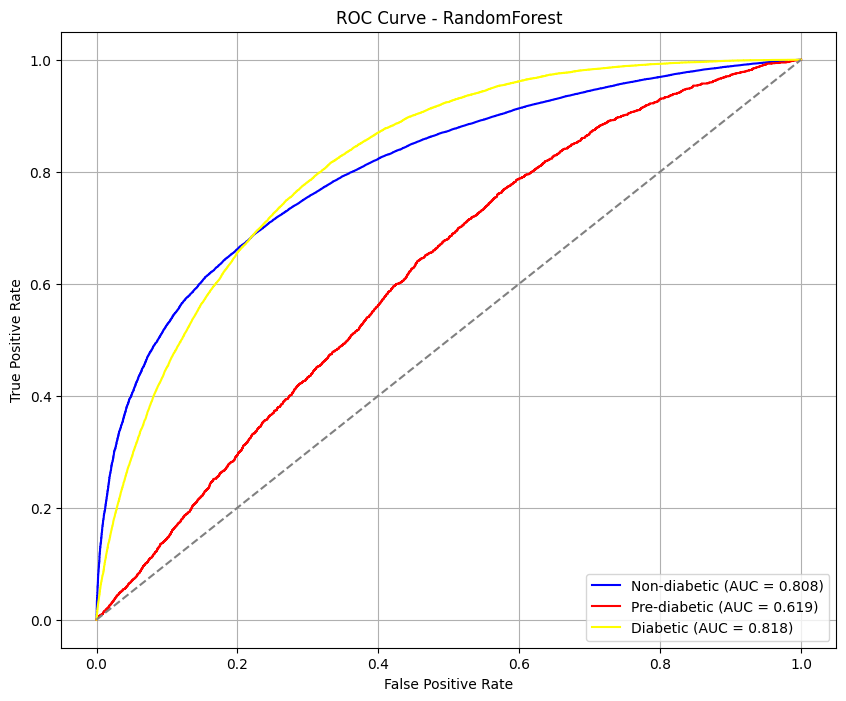

In [47]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rf_class_probabilities,
    model_name="RandomForest"
)

In [48]:
# Evaluate Random Forest with cross-validation
rf_model_cv_scores = rf_model.cross_validate(X=X_train_normalized, y=y_train)
rf_model_cv_scores

2025-09-28 04:34:53,965 - [models.random_forest] - INFO - Cross-validation results:
2025-09-28 04:34:53,967 - [models.random_forest] - INFO - Mean accuracy: 0.7426 (+/- 0.0036)


array([0.7439282 , 0.7454194 , 0.74181567, 0.74046255, 0.74146692])

### **3.5 XGBoost**

In [49]:
# Initialize and configure a XGBoost model
xgb_model = DiabetesXGBoostClassifier(
    n_estimators=XGB_N_ESTIMATORS,
    max_depth=XGB_MAX_DEPTH, 
    learning_rate=XGB_LEARNING_RATE, 
    subsample=XGB_SUBSAMPLE, 
    colsample_bytree=XGB_COLSAMPLE_BY_TREE, 
    logger_name="models.xgboost",
    log_file=f"{LOG_DIR}/2_model_training_with_original_data.log",
)

2025-09-28 04:34:53,978 - [models.xgboost] - INFO - DiabetesXGBoostClassifier initialized with parameters:
2025-09-28 04:34:53,979 - [models.xgboost] - INFO -  n_estimators: 100
2025-09-28 04:34:53,980 - [models.xgboost] - INFO -  max_depth: 6
2025-09-28 04:34:53,981 - [models.xgboost] - INFO -  learning_rate: 0.1
2025-09-28 04:34:53,981 - [models.xgboost] - INFO -  subsample: 1.0
2025-09-28 04:34:53,982 - [models.xgboost] - INFO -  colsample_bytree: 1.0
2025-09-28 04:34:53,983 - [models.xgboost] - INFO -  random_state: 42


In [50]:
# Get the model information
xgb_model.get_model_info()

{'n_estimators': 100,
 'max_depth': 6,
 'learning_rate': 0.1,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': None}

In [51]:
# Train the XGBoost model on normalized training data
xgb_model.train(X=X_train_normalized, y=y_train)

2025-09-28 04:34:54,008 - [models.xgboost] - INFO - Starting XGBoost model training...
2025-09-28 04:35:02,736 - [models.xgboost] - INFO - Model training completed. Training samples: 362124


In [52]:
# Generate predictions
xgb_y_pred = xgb_model.predict(X=X_test_normalized)

2025-09-28 04:35:02,977 - [models.xgboost] - INFO - Predictions made for 90531 samples


In [53]:
# Display the first 10 predictions to verify the output format
xgb_y_pred[:10]

array([2, 0, 0, 0, 0, 0, 0, 0, 0, 2])

In [54]:
# Evaluate XGBoost model
xgb_model_eval_results = xgb_model.evaluate(y_true=y_test, y_pred=rf_y_pred)

2025-09-28 04:35:03,078 - [models.xgboost] - INFO - Model Evaluation Results:
2025-09-28 04:35:03,079 - [models.xgboost] - INFO - Accuracy: 0.7409
2025-09-28 04:35:03,079 - [models.xgboost] - INFO - Precision: 0.4483
2025-09-28 04:35:03,080 - [models.xgboost] - INFO - Recall: 0.4937
2025-09-28 04:35:03,081 - [models.xgboost] - INFO - F1-Score: 0.4537
2025-09-28 04:35:03,126 - [models.xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.78      0.83     71499
         1.0       0.04      0.01      0.01      2399
         2.0       0.41      0.70      0.52     16633

    accuracy                           0.74     90531
   macro avg       0.45      0.49      0.45     90531
weighted avg       0.79      0.74      0.75     90531

2025-09-28 04:35:03,170 - [models.xgboost] - INFO - Confusion Matrix:
[[55450   361 15688]
 [ 1266    18  1115]
 [ 4907   116 11610]]


In [55]:
# Display model performance metrics
xgb_model_eval_results

{'accuracy': 0.7409395676619058,
 'precision': 0.4482685914553886,
 'recall': 0.49368280954496235,
 'f1_score': 0.4536610062144664}

In [56]:
# Predict class probabilities
xgb_class_probabilities = xgb_model.predict_proba(X=X_test_normalized)

2025-09-28 04:35:03,359 - [models.xgboost] - INFO - Probabilities predicted for 90531 samples


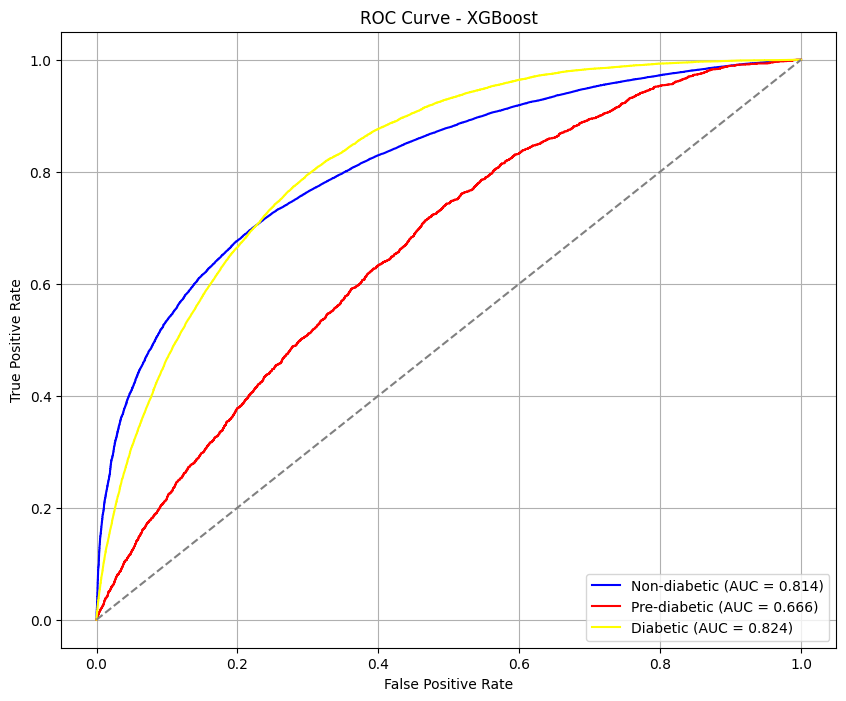

In [57]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=xgb_class_probabilities,
    model_name="XGBoost"
)

In [58]:
# Evaluate XGBoost with cross-validation
xgb_model_cv_scores = xgb_model.cross_validate(X=X_train_normalized, y=y_train)
xgb_model_cv_scores

2025-09-28 04:35:35,479 - [models.xgboost] - INFO - Cross-validation results:
2025-09-28 04:35:35,480 - [models.xgboost] - INFO - Mean accuracy: 0.8089 (+/- 0.0008)


array([0.80850535, 0.80875388, 0.80960994, 0.80875388, 0.80862697])

### **3.6 LightGBM**


In [59]:
# Initialize and configure a LightGBM model
lgbm_model = DiabetesLightGBMClassifier(
    n_estimators=LGBM_N_ESTIMATORS, 
    max_depth=LGBM_MAX_DEPTH, 
    learning_rate=LGBM_LEARNING_RATE, 
    num_leaves=LGBM_NUM_LEAVES, 
    subsample=LGBM_SUBSAMPLE, 
    colsample_bytree=LGBM_COLSAMPLE_BY_TREE,  
    logger_name="models.lightgbm",
    log_file=f"{LOG_DIR}/2_model_training_with_original_data.log",
)

2025-09-28 04:35:35,508 - [models.lightgbm] - INFO - DiabetesLightGBMClassifier initialized with parameters:
2025-09-28 04:35:35,510 - [models.lightgbm] - INFO -  n_estimators: 100
2025-09-28 04:35:35,511 - [models.lightgbm] - INFO -  max_depth: -1
2025-09-28 04:35:35,512 - [models.lightgbm] - INFO -  learning_rate: 0.1
2025-09-28 04:35:35,513 - [models.lightgbm] - INFO -  num_leaves: 31
2025-09-28 04:35:35,513 - [models.lightgbm] - INFO -  subsample: 1.0
2025-09-28 04:35:35,515 - [models.lightgbm] - INFO -  colsample_bytree: 1.0
2025-09-28 04:35:35,517 - [models.lightgbm] - INFO -  random_state: 42


In [60]:
# Get the model information
lgbm_model.get_model_info()

{'n_estimators': 100,
 'max_depth': -1,
 'learning_rate': 0.1,
 'num_leaves': 31,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': None}

In [61]:
# Train the LightGBM model on normalized training data
lgbm_model.train(X=X_train_normalized, y=y_train)

2025-09-28 04:35:35,542 - [models.lightgbm] - INFO - Starting LightGBM model training...


[LightGBM] [Info] Total Bins 262
[LightGBM] [Info] Number of data points in the train set: 362124, number of used features: 32
[LightGBM] [Info] Start training from score -0.235998
[LightGBM] [Info] Start training from score -3.630745
[LightGBM] [Info] Start training from score -1.694334


2025-09-28 04:35:40,608 - [models.lightgbm] - INFO - Model training completed. Training samples: 362124


In [62]:
# Generate predictions
lgbm_y_pred = lgbm_model.predict(X=X_test_normalized)

2025-09-28 04:35:41,330 - [models.lightgbm] - INFO - Predictions made for 90531 samples


In [63]:
# Display the first 10 predictions to verify the output format
lgbm_y_pred[:10]

array([2., 0., 0., 0., 0., 0., 0., 0., 0., 2.])

In [64]:
# Evaluate LightGBM model
lgbm_model_eval_results = lgbm_model.evaluate(y_true=y_test, y_pred=rf_y_pred)

2025-09-28 04:35:41,402 - [models.lightgbm] - INFO - Model Evaluation Results:
2025-09-28 04:35:41,403 - [models.lightgbm] - INFO - Accuracy: 0.7409
2025-09-28 04:35:41,404 - [models.lightgbm] - INFO - Precision: 0.4483
2025-09-28 04:35:41,405 - [models.lightgbm] - INFO - Recall: 0.4937
2025-09-28 04:35:41,407 - [models.lightgbm] - INFO - F1-Score: 0.4537
2025-09-28 04:35:41,454 - [models.lightgbm] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.78      0.83     71499
         1.0       0.04      0.01      0.01      2399
         2.0       0.41      0.70      0.52     16633

    accuracy                           0.74     90531
   macro avg       0.45      0.49      0.45     90531
weighted avg       0.79      0.74      0.75     90531

2025-09-28 04:35:41,498 - [models.lightgbm] - INFO - Confusion Matrix:
[[55450   361 15688]
 [ 1266    18  1115]
 [ 4907   116 11610]]


In [65]:
# Display model performance metrics
lgbm_model_eval_results

{'accuracy': 0.7409395676619058,
 'precision': 0.4482685914553886,
 'recall': 0.49368280954496235,
 'f1_score': 0.4536610062144664}

In [66]:
# Predict class probabilities
lgbm_class_probabilities = lgbm_model.predict_proba(X=X_test_normalized)

2025-09-28 04:35:42,295 - [models.lightgbm] - INFO - Probabilities predicted for 90531 samples


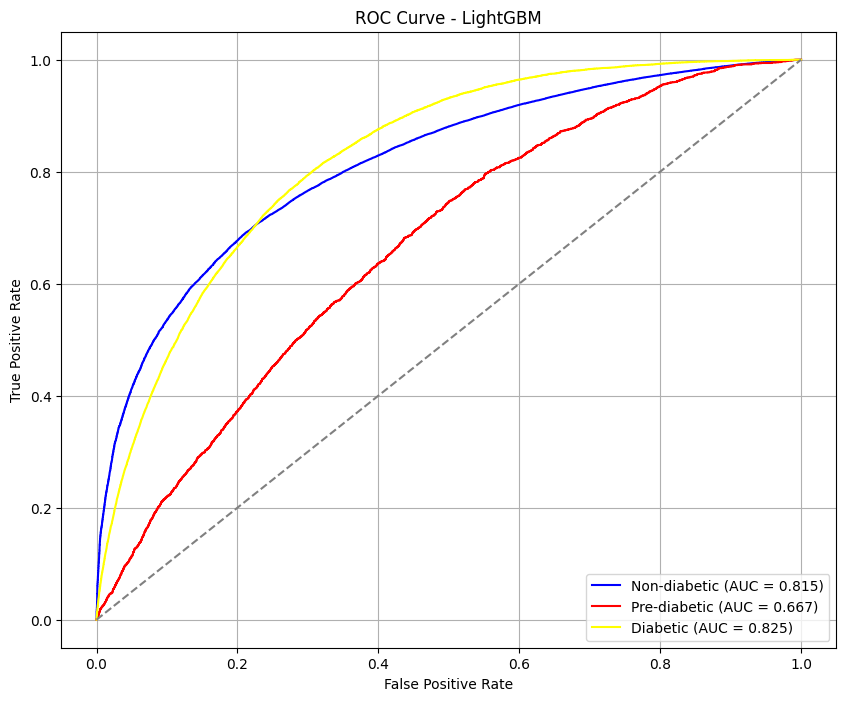

In [67]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=lgbm_class_probabilities,
    model_name="LightGBM"
)

In [68]:
# Evaluate LightGBM with cross-validation
lgbm_model_cv_scores = lgbm_model.cross_validate(X=X_train_normalized, y=y_train)
lgbm_model_cv_scores

[LightGBM] [Info] Total Bins 264
[LightGBM] [Info] Number of data points in the train set: 289699, number of used features: 32
[LightGBM] [Info] Start training from score -0.235999
[LightGBM] [Info] Start training from score -3.630744
[LightGBM] [Info] Start training from score -1.694333
[LightGBM] [Info] Total Bins 264
[LightGBM] [Info] Number of data points in the train set: 289699, number of used features: 32
[LightGBM] [Info] Start training from score -0.235999
[LightGBM] [Info] Start training from score -3.630744
[LightGBM] [Info] Start training from score -1.694333
[LightGBM] [Info] Total Bins 264
[LightGBM] [Info] Number of data points in the train set: 289699, number of used features: 32
[LightGBM] [Info] Start training from score -0.235999
[LightGBM] [Info] Start training from score -3.630744
[LightGBM] [Info] Start training from score -1.694333
[LightGBM] [Info] Total Bins 263
[LightGBM] [Info] Number of data points in the train set: 289699, number of used features: 32
[Light

2025-09-28 04:36:06,086 - [models.lightgbm] - INFO - Cross-validation results:
2025-09-28 04:36:06,087 - [models.lightgbm] - INFO - Mean accuracy: 0.8090 (+/- 0.0011)


array([0.80951329, 0.80843631, 0.80963756, 0.80890576, 0.80837844])

## **4. Compare models**

In [69]:
# Compare all models' performance on the test set and display the comprehensive metrics table
models = {
    "SGDClassifier": sgd_model,
    "LogisticRegression": lr_model,
    "NaiveBayes": nb_model,
    "RandomForest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}
comparison_results = compare_models(
    models_dict=models, 
    X_test=X_test_normalized, 
    y_true=y_test
)

2025-09-28 04:36:06,117 - [models.sgd_classifier] - INFO - Predictions made for 90531 samples
2025-09-28 04:36:06,162 - [models.sgd_classifier] - INFO - Probabilities predicted for 90531 samples


2025-09-28 04:36:06,472 - [models.logistic_regression] - INFO - Predictions made for 90531 samples
2025-09-28 04:36:06,503 - [models.logistic_regression] - INFO - Probabilities predicted for 90531 samples
2025-09-28 04:36:06,746 - [models.naive_bayes] - INFO - Predictions made for 90531 samples
2025-09-28 04:36:06,800 - [models.naive_bayes] - INFO - Probabilities predicted for 90531 samples
2025-09-28 04:36:09,137 - [models.random_forest] - INFO - Predictions made for 90531 samples
2025-09-28 04:36:11,235 - [models.random_forest] - INFO - Probabilities predicted for 90531 samples
2025-09-28 04:36:11,454 - [models.xgboost] - INFO - Predictions made for 90531 samples
2025-09-28 04:36:11,587 - [models.xgboost] - INFO - Probabilities predicted for 90531 samples
2025-09-28 04:36:12,385 - [models.lightgbm] - INFO - Predictions made for 90531 samples
2025-09-28 04:36:13,081 - [models.lightgbm] - INFO - Probabilities predicted for 90531 samples


In [70]:
# Comparison results
comparison_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2
0,SGDClassifier,0.8037,0.7947,0.4114,0.4202,0.7566,0.8293,1.0000,0.5549,0.9520,0.0000,0.2821,0.8864,0.0000,0.3740
1,LogisticRegression,0.8046,0.7986,0.4056,0.4142,0.7602,0.8259,1.0000,0.5699,0.9587,0.0000,0.2582,0.8874,0.0000,0.3554
2,NaiveBayes,0.7108,0.4322,0.4616,0.4377,0.7103,0.8728,0.0552,0.3686,0.7641,0.0425,0.5782,0.8148,0.0480,0.4502
3,RandomForest,0.7409,0.4483,0.4937,0.4537,0.7483,0.8998,0.0364,0.4086,0.7755,0.0075,0.6980,0.8331,0.0124,0.5155
4,XGBoost,0.8094,0.8074,0.4144,0.4248,0.7683,0.8305,1.0000,0.5919,0.9587,0.0000,0.2845,0.8900,0.0000,0.3843
5,LightGBM,0.8091,0.8059,0.4163,0.4266,0.7688,0.8316,1.0000,0.5861,0.9565,0.0000,0.2924,0.8897,0.0000,0.3902


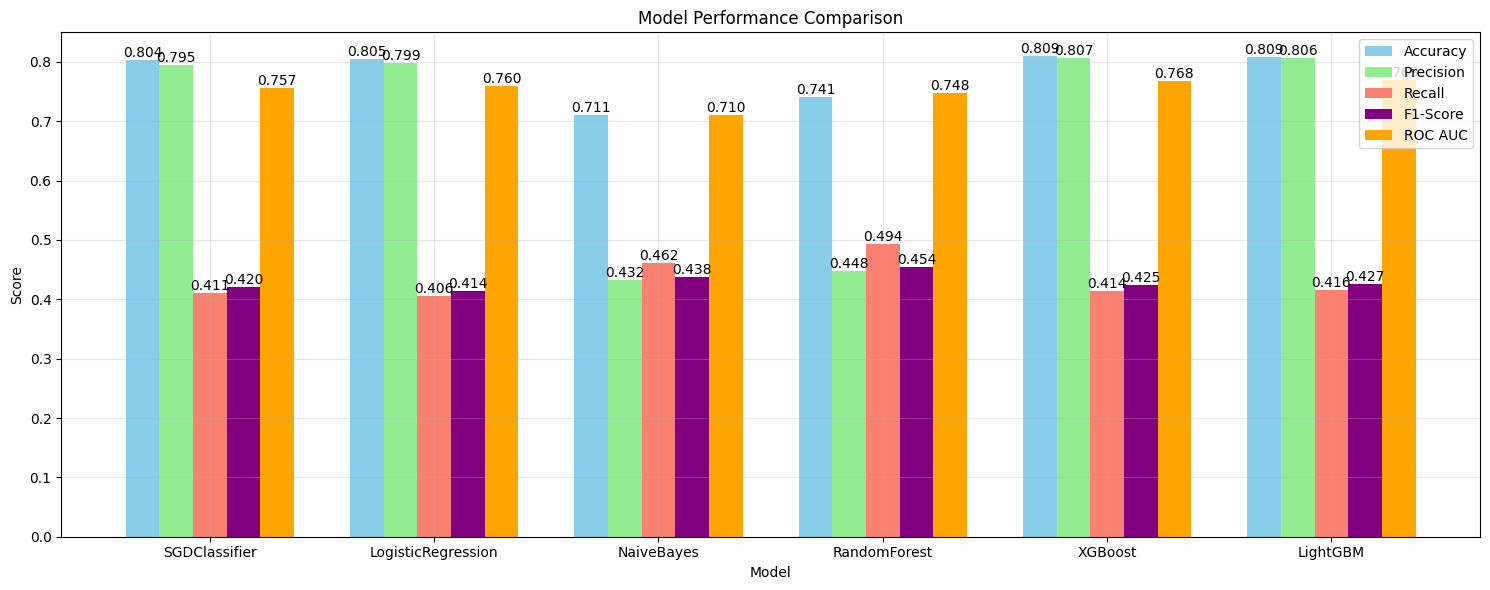

In [71]:
# Model comparison plot
plot_compare_models(comparison_df=comparison_results)